# Chapter 124 — Vector Representation

> **Prerequisites:** Vectors in Programming (ch123), Geometric Interpretation (ch122), trigonometry (ch101–103)
> **You will learn:**
> - Cartesian representation vs polar representation
> - Column vectors vs row vectors — and why the distinction matters
> - Converting between representations
> - How high-dimensional vectors are represented even when they cannot be drawn

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A vector is an abstract object. To work with it computationally, we need a **representation**: a way of writing the vector as an ordered collection of numbers.

The most common representation is **Cartesian coordinates** — the components along each axis. But there are others. In 2D, a vector can also be represented as **(magnitude, angle)** — the polar form. Both representations encode the same vector.

A second dimension of representation choice: **column vector** vs **row vector**.

$$\text{Column: } \mathbf{v} = \begin{pmatrix} 1 \\ 2 \\ 3 \end{pmatrix} \qquad \text{Row: } \mathbf{v}^T = \begin{pmatrix} 1 & 2 & 3 \end{pmatrix}$$

Mathematically, these are different objects (a column vector has shape n×1, a row vector has shape 1×n). In NumPy, a 1D array `np.array([1, 2, 3])` has shape `(3,)` and is neither — it becomes column or row depending on context. This is the source of many subtle bugs.

**Common misconception:** A NumPy 1D array `shape=(n,)` is *not* the same as a column vector `shape=(n,1)` or a row vector `shape=(1,n)`. Operations like matrix multiplication will behave differently.

---

## 2. Intuition & Mental Models

**Polar model:** Think of any 2D vector as an arm of a clock. The length of the arm is the magnitude. The angle it makes with the positive x-axis is the direction. These two numbers — length and angle — determine the arm completely.

**Coordinate model:** Think of the same arm as a staircase: walk some distance right (x-component), then some distance up (y-component). The staircase has the same net effect as the arm.

**Column vs row:** By mathematical convention (and ML convention), vectors are columns — vertical lists. Row vectors are their transposes. In NumPy, always prefer shape `(n,)` for standalone vectors, and be explicit about shape when doing matrix operations.

Recall from ch101–103 (Trigonometry, Sine and Cosine, Unit Circle) that $x = r\cos\theta$ and $y = r\sin\theta$ give the Cartesian components from polar.

---

## 3. Visualization

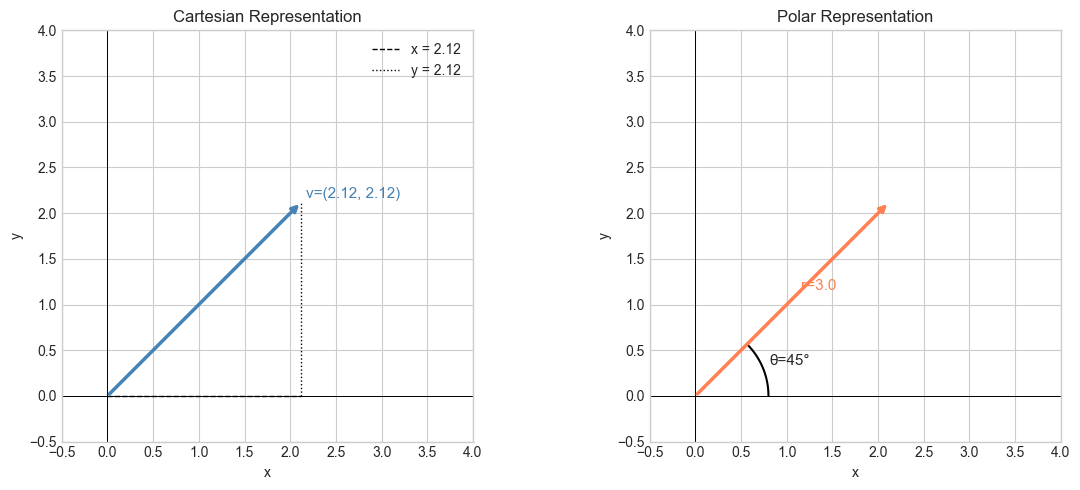

In [1]:
# --- Visualization: Cartesian vs polar representation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Define a vector in polar: magnitude r, angle theta (radians)
r     = 3.0
theta = np.pi / 4   # 45 degrees

# Convert to Cartesian
x = r * np.cos(theta)
y = r * np.sin(theta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: Cartesian ----
ax = axes[0]
ax.annotate('', xy=(x, y), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.plot([0, x], [0, 0], 'k--', lw=1, label=f'x = {x:.2f}')
ax.plot([x, x], [0, y], 'k:',  lw=1, label=f'y = {y:.2f}')
ax.text(x+0.05, y+0.05, f'v=({x:.2f}, {y:.2f})', fontsize=11, color='steelblue')
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Cartesian Representation')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

# ---- Right: Polar ----
ax = axes[1]
ax.annotate('', xy=(x, y), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='coral', lw=2.5))
# Draw arc for angle
arc_angles = np.linspace(0, theta, 50)
ARC_R = 0.8
ax.plot(ARC_R * np.cos(arc_angles), ARC_R * np.sin(arc_angles), 'k-', lw=1.5)
ax.text(ARC_R*1.1*np.cos(theta/2), ARC_R*1.1*np.sin(theta/2),
        f'θ={np.degrees(theta):.0f}°', fontsize=11)
# Label magnitude
mid = np.array([x/2, y/2])
ax.text(mid[0]+0.1, mid[1]+0.1, f'r={r:.1f}', fontsize=11, color='coral')
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Polar Representation')
ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Cartesian to Polar (2D):**

$$r = \|\mathbf{v}\| = \sqrt{v_x^2 + v_y^2}$$

$$\theta = \text{atan2}(v_y, v_x)$$

Where:
- $r$ = magnitude (length) of the vector
- $\theta$ = angle from positive x-axis (in radians)
- `atan2` is used instead of `atan` to handle all four quadrants correctly

**Polar to Cartesian:**

$$v_x = r \cos\theta \qquad v_y = r \sin\theta$$

**Column vs row in NumPy shapes:**

```
v      = np.array([1, 2, 3])     # shape (3,)  — "flat" vector
v_col  = v.reshape(-1, 1)        # shape (3,1) — column vector
v_row  = v.reshape(1, -1)        # shape (1,3) — row vector
```

In [2]:
# --- Mathematical Formulation: conversion functions ---
import numpy as np

def cartesian_to_polar(v):
    """
    Convert 2D Cartesian vector to polar (r, theta).

    Args:
        v: ndarray shape (2,)

    Returns:
        (r, theta) where r >= 0 and theta in (-pi, pi]
    """
    r = np.linalg.norm(v)
    theta = np.arctan2(v[1], v[0])  # atan2 handles all quadrants
    return r, theta


def polar_to_cartesian(r, theta):
    """
    Convert polar (r, theta) to 2D Cartesian vector.

    Args:
        r: float, magnitude >= 0
        theta: float, angle in radians

    Returns:
        ndarray shape (2,)
    """
    return np.array([r * np.cos(theta), r * np.sin(theta)])


# Test round-trip
for v in [np.array([3.0, 0.0]), np.array([0.0, 2.0]),
          np.array([-1.0, 1.0]), np.array([3.0, -4.0])]:
    r, theta = cartesian_to_polar(v)
    v_back = polar_to_cartesian(r, theta)
    err = np.linalg.norm(v - v_back)
    print(f"v={v}  r={r:.3f}  theta={np.degrees(theta):.1f}°  round-trip error={err:.2e}")

v=[3. 0.]  r=3.000  theta=0.0°  round-trip error=0.00e+00
v=[0. 2.]  r=2.000  theta=90.0°  round-trip error=1.22e-16
v=[-1.  1.]  r=1.414  theta=135.0°  round-trip error=2.22e-16
v=[ 3. -4.]  r=5.000  theta=-53.1°  round-trip error=6.28e-16


## 5. Python Implementation

In [3]:
# --- Implementation: Shape handling for column/row vectors ---
import numpy as np

def as_column(v):
    """
    Return v as a column vector with shape (n, 1).

    Args:
        v: ndarray shape (n,) or (n,1)

    Returns:
        ndarray shape (n,1)
    """
    v = np.asarray(v, dtype=float)
    return v.reshape(-1, 1)


def as_row(v):
    """
    Return v as a row vector with shape (1, n).

    Args:
        v: ndarray shape (n,) or (n,1)

    Returns:
        ndarray shape (1,n)
    """
    v = np.asarray(v, dtype=float)
    return v.reshape(1, -1)


def as_flat(v):
    """
    Return v as a flat vector with shape (n,).

    Args:
        v: ndarray of any compatible shape

    Returns:
        ndarray shape (n,)
    """
    return np.asarray(v, dtype=float).flatten()


v = np.array([1.0, 2.0, 3.0])
print("Flat   shape:", as_flat(v).shape)
print("Column shape:", as_column(v).shape)
print("Row    shape:", as_row(v).shape)
print()
print("Column vector:\n", as_column(v))
print("Row vector:\n", as_row(v))

Flat   shape: (3,)
Column shape: (3, 1)
Row    shape: (1, 3)

Column vector:
 [[1.]
 [2.]
 [3.]]
Row vector:
 [[1. 2. 3.]]


## 6. Experiments

In [4]:
# --- Experiment 1: Quadrant behavior of atan2 ---
# Hypothesis: atan2 correctly identifies angle for all four quadrants.
# Try changing: the vector components to explore each quadrant.
import numpy as np

VECTORS = [
    np.array([ 1.0,  0.0]),   # East — 0°
    np.array([ 0.0,  1.0]),   # North — 90°
    np.array([-1.0,  0.0]),   # West — 180°
    np.array([ 0.0, -1.0]),   # South — -90°
    np.array([-1.0, -1.0]),   # SW  — modify this
]

for v in VECTORS:
    theta_rad = np.arctan2(v[1], v[0])
    theta_deg = np.degrees(theta_rad)
    print(f"v={v}  theta={theta_deg:7.2f}°")

v=[1. 0.]  theta=   0.00°
v=[0. 1.]  theta=  90.00°
v=[-1.  0.]  theta= 180.00°
v=[ 0. -1.]  theta= -90.00°
v=[-1. -1.]  theta=-135.00°


In [5]:
# --- Experiment 2: Shape gotchas in NumPy ---
# Hypothesis: operations between (3,) and (3,1) arrays behave differently than expected.
# Try changing: the shapes and observe the output shape.
import numpy as np

v_flat = np.array([1.0, 2.0, 3.0])         # shape (3,)
v_col  = np.array([[1.0], [2.0], [3.0]])    # shape (3,1)
v_row  = np.array([[1.0, 2.0, 3.0]])        # shape (1,3)

print("Shapes:", v_flat.shape, v_col.shape, v_row.shape)
print()

# What shape does multiplication produce?
print("flat * flat:", (v_flat * v_flat).shape)   # (3,)
print("col * row:  ", (v_col  * v_row).shape)     # (3,3) — outer product!
print("row * col:  ", (v_row  * v_col).shape)     # (3,3)
print("flat * col: ", (v_flat * v_col).shape)     # broadcasts to (3,3)

Shapes: (3,) (3, 1) (1, 3)

flat * flat: (3,)
col * row:   (3, 3)
row * col:   (3, 3)
flat * col:  (3, 3)


## 7. Exercises

**Easy 1.** Convert the vector **v** = (3, 4) from Cartesian to polar. What is its magnitude? What angle does it make with the x-axis? *(Expected: r=5, theta≈53.13°)*

**Easy 2.** Convert polar **(r=2, theta=120°)** to Cartesian. *(Expected: (-1, 1.732))*

**Medium 1.** Write a function `polar_to_cartesian_batch(rs, thetas)` that converts arrays of radii and angles to an array of Cartesian vectors. Shape of output: `(n, 2)`. Test with 5 vectors.

**Medium 2.** Create a 4D vector **v** = (1, 2, 3, 4). Reshape it as a column vector (4, 1) and a row vector (1, 4). Multiply column by row — what shape is the result? What is the result's entry at position (i, j)? *(Hint: outer product — connects to ch131)*

**Hard.** The angle `theta` from `atan2` lies in `(-π, π]`. Write a function `normalize_angle(theta)` that converts any angle to `[0, 2π)`. Verify that `cartesian_to_polar → polar_to_cartesian` is a perfect round-trip for 100 random vectors. What precision do you observe?

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Radar Display ---
# Problem: A radar system tracks objects using polar coordinates (range, bearing).
#          Convert to Cartesian and display on a 2D grid.
# Dataset: simulated radar returns
# Task: implement conversion, filter objects within a safe zone, display results

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Radar returns: (range_km, bearing_degrees clockwise from North)
# North is +y in Cartesian coordinates
radar_returns = np.array([
    [5.2,  30],
    [8.1,  120],
    [3.0,  200],
    [10.5, 315],
    [6.7,  45],
    [2.1,  90],
    [9.0,  270],
    [4.4,  160],
])

SAFE_ZONE_RADIUS = 5.0  # km — objects within this are a concern

def radar_to_cartesian(range_km, bearing_deg):
    """
    Convert radar polar coordinates to Cartesian (x=East, y=North).

    Args:
        range_km: float
        bearing_deg: float, degrees clockwise from North

    Returns:
        (x, y): tuple of floats
    """
    # TODO: implement (North = +y, clockwise bearing)
    pass

# TODO: convert all returns, identify those within safe zone radius, visualize

## 9. Summary & Connections

- Cartesian representation: components along each axis — the standard for computation.
- Polar representation: magnitude and angle — natural for rotation and direction problems.
- Column vs row vs flat: shape matters for matrix multiplication. Default to `(n,)` unless doing matrix algebra.
- `np.arctan2(y, x)` handles all quadrants correctly; `np.arctan(y/x)` does not.

**Backward connection:** This applies the unit circle and trigonometry from ch103. The polar-to-Cartesian formula $x = r\cos\theta$, $y = r\sin\theta$ is directly the unit circle definition.

**Forward connections:**
- This will reappear in ch128 — Vector Length (Norm), where the Cartesian-to-polar radius formula becomes the Euclidean norm.
- This will reappear in ch133 — Angles Between Vectors, where the angle between two vectors is computed without converting to polar.
- This will reappear in ch151 — Introduction to Matrices (Part VI), where column vectors are the standard input/output type for matrix multiplication.